# Uncertainty Explainer — Demo Workflow

Este notebook muestra el pipeline completo de la librería:

1. **Datos**: generamos un dataset de regresión sintético
2. **Modelo**: entrenamos un `RandomForestRegressor`
3. **Predicción conformal**: calibramos intervalos de predicción
4. **Explicación**: Explicamos la incertidumbre generada por la predicción conformal.
    - ***Valores Shapley***: explicamos qué features contribuyen a la incertidumbre (ancho del intervalo)
    - ***Partial Dependence Plot (PDP)***: Explicamos cómo cambia la incertidumbre media del modelo cuando cambia las features seleccionadas (efecto marginal).
    - ***LIME***: Para un punto de interés, se ajusta un modelo interpretable localmente que permita interpretar los parámetros sobre la amplitud del intervalo como variable de respuesta.

In [18]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from uncertainty_explainer import (
    CQRConformalPredictor,
    UncertaintyExplanationPipeline,
)

## 1. Data

We generate a synthetic dataset and wrap it in a `DataFrame` so that feature names propagate automatically to the explanations.

In [ ]:
X, y = make_regression(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    noise=25.0,
    random_state=42,
)

feature_names = [f"feat_{i}" for i in range(X.shape[1])]
X = pd.DataFrame(X, columns=feature_names)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibration: {X_calib.shape[0]}, Test: {X_test.shape[0]}")
X_train.head()

## 2. Quickstart (3 lines): most basic case for a user

The minimal API only requires a model. `conformal_method`, `confidence`, `xai_method`, and the calibration split all use sensible defaults. The `ExplanationResult` already carries the intervals (`lower`, `upper`, `interval_width`) — there is no need to call `predict()` separately.

In [ ]:
quick = UncertaintyExplanationPipeline(model=RandomForestRegressor(random_state=42))
quick.fit(X_train, y_train)
result = quick.explain(X_test, show_plots=False)

print(f"Coverage: {np.mean((y_test >= result.lower) & (y_test <= result.upper)):.3f}")
print(f"Mean interval width: {result.interval_width.mean():.2f}")

X, y = make_regression(
    n_samples=1000,
    n_features=5,
    n_informative=5,
    noise=25.0,
    random_state=42,
)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_calib, X_test, y_calib, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {X_train.shape[0]}, Calibracion: {X_calib.shape[0]}, Test: {X_test.shape[0]}")

## 2. Crear el pipeline

El pipeline recibe un regresor sklearn, un método conformal y un método xai.

Metodos conformales soportados (`conformal_method`):
- `"standard"` — conformal basico, intervalos de ancho fijo para todas las instancias
- `"normalized"` — usa `DifficultyEstimator` para adaptar el ancho segun la dificultad de cada instancia (default)
- `"mondrian"` — usa `MondrianCategorizer` para cobertura condicional por grupo
- `"normalized_mondrian"` — combina DifficultyEstimator + MondrianCategorizer

Métodos XAI soportados (`xai_method`):
- `"shap"`
- `"pdp"`
- `"lime"`

## Explanation using valores shapley

In [4]:
quick = UncertaintyExplanationPipeline(model=RandomForestRegressor(random_state=42))
quick.fit(X_train, y_train)
result = quick.explain_uncertainty(X_test, show_plots=False)

print(f"Coverage: {np.mean((y_test >= result.lower) & (y_test <= result.upper)):.3f}")
print(f"Mean interval width: {result.interval_width.mean():.2f}")

ExactExplainer explainer: 201it [00:47,  4.24it/s]                         


Coverage: 0.870
Mean interval width: 107.65


In [6]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

pipeline_shap = UncertaintyExplanationPipeline(
    model=model,
    confidence=0.9,
    conformal_method="normalized",
)

### 3. Entrenar y calibrar

pipeline_shap.fit(X_train, y_train, X_calib, y_calib)

In [7]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

### 4. Explicar la incertidumbre

`explain_uncertainty()` calcula valores SHAP sobre el ancho del intervalo conformal y genera plots automaticamente (beeswarm, bar, waterfall).

Este método explicar la métrica de incertidumbre tanto de manera local como global. Si el usuario sólo quiere explicar un punto sólo genera el plot waterfall.

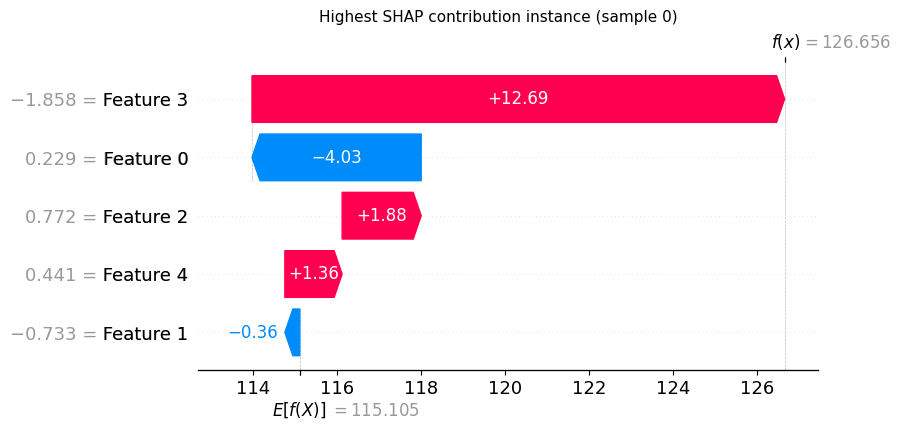

In [7]:
result = pipeline.explain_uncertainty(X_test[1:2, :])

En el caso se explicación global:

ExactExplainer explainer: 201it [00:30,  4.37it/s]                         


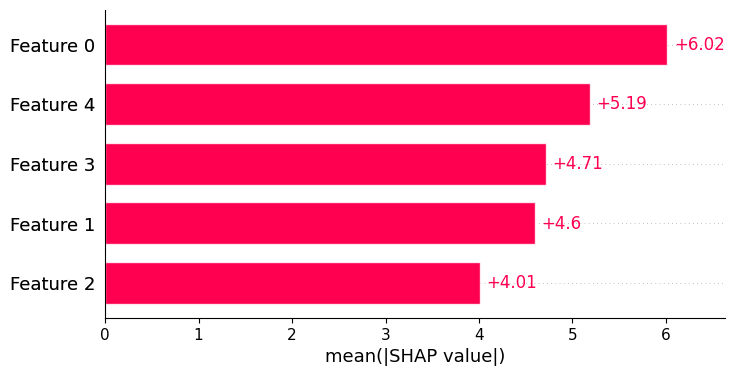

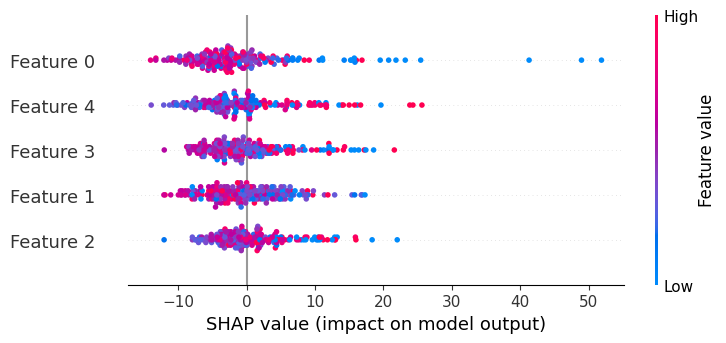

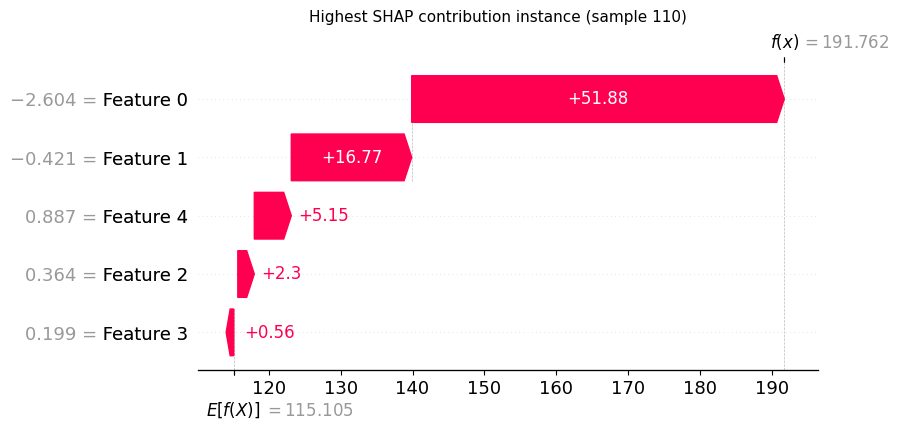

In [8]:
result = pipeline.explain_uncertainty(X_test)

### 5. Resultados

El diccionario retornado contiene los intervalos de prediccion y los valores SHAP.

In [9]:
print("Keys:", list(vars(result).keys()))
print(f"\nIntervalo promedio: {result.interval_width.mean():.2f}")
print(f"Intervalo min: {result.interval_width.min():.2f}")
print(f"Intervalo max: {result.interval_width.max():.2f}")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 115.07
Intervalo min: 73.81
Intervalo max: 191.76


In [10]:
# SHAP values: cada fila es una instancia, cada columna la contribucion de un feature al ancho del intervalo
print("SHAP values shape:", result.explanation_values.values.shape)
print("\nEjemplo — contribucion de cada feature para la primera instancia de test:")
for i, val in enumerate(result.explanation_values.values[0]):
    print(f"  Feature {i}: {val:+.4f}")

SHAP values shape: (200, 5)

Ejemplo — contribucion de cada feature para la primera instancia de test:
  Feature 0: -11.3912
  Feature 1: -2.1076
  Feature 2: +2.1402
  Feature 3: +4.9162
  Feature 4: +6.5928


## Explanation using Partial Dependence Plots (PDP)

In [8]:
print("ExplanationResult fields:", list(vars(result_shap).keys()))
print(f"SHAP values shape: {result_shap.explanation_values.values.shape}")
print(f"\nMean interval width: {result_shap.interval_width.mean():.2f}")
print(f"Min interval width:  {result_shap.interval_width.min():.2f}")
print(f"Max interval width:  {result_shap.interval_width.max():.2f}")

## 4. Alternative explainer — PDP

`PDPUncertaintyExplainer` builds Partial Dependence Plots over the interval-width function.

**Supported kinds**: `"pdp"`, `"ice"`, `"pdp_ice"`, `"importance"` (Greenwell et al.-style importance — standard deviation of the PDP curve).

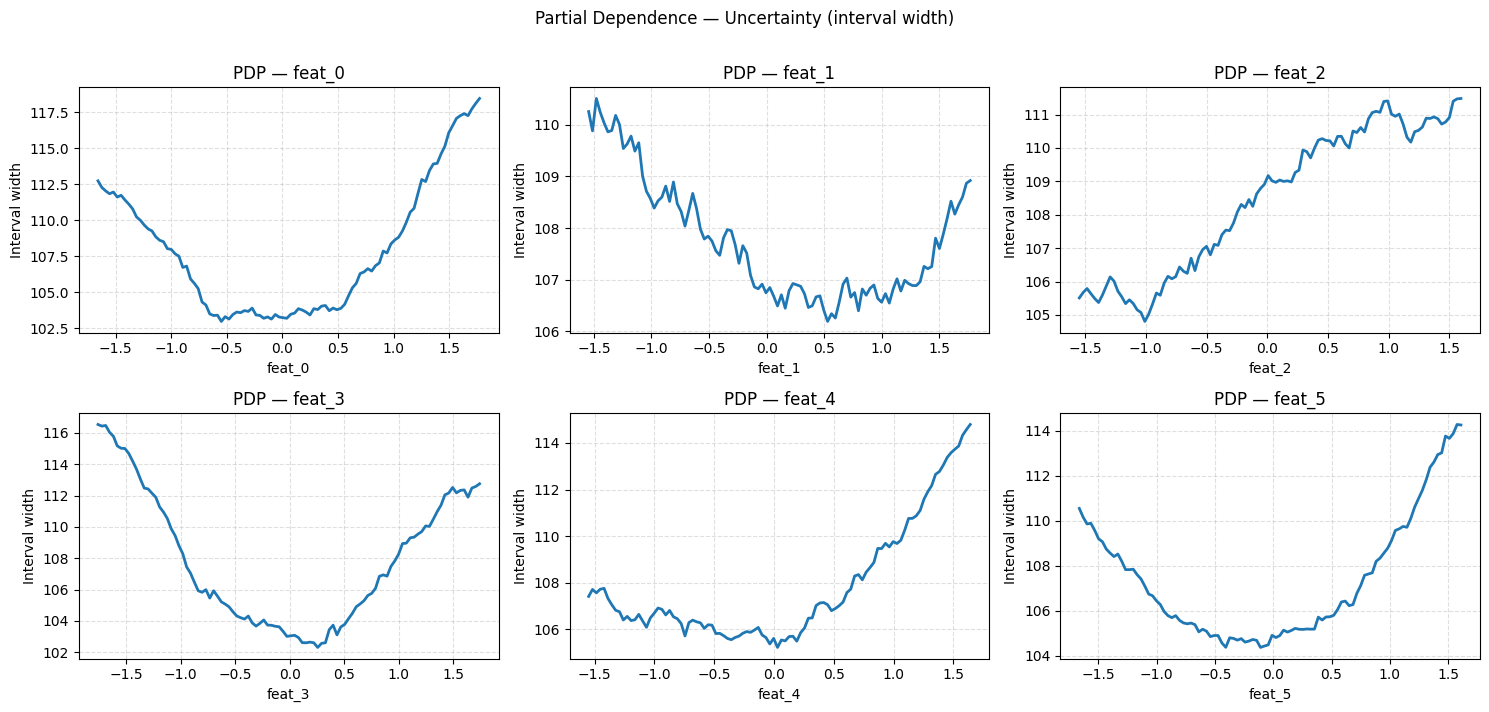

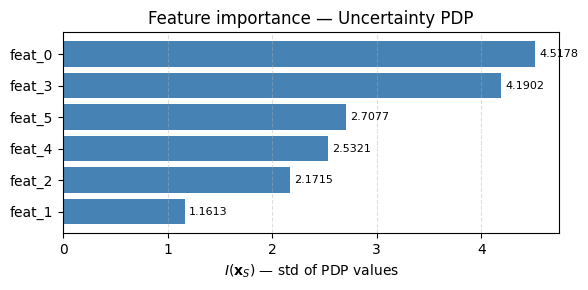

In [26]:
pipeline_pdp = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="pdp",
)

pipeline_pdp.fit(X_train, y_train, X_calib, y_calib)
result_pdp = pipeline_pdp.explain(
    X_test,
    plot_kind=["pdp", "importance"],
    kind="average",
)

In [9]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

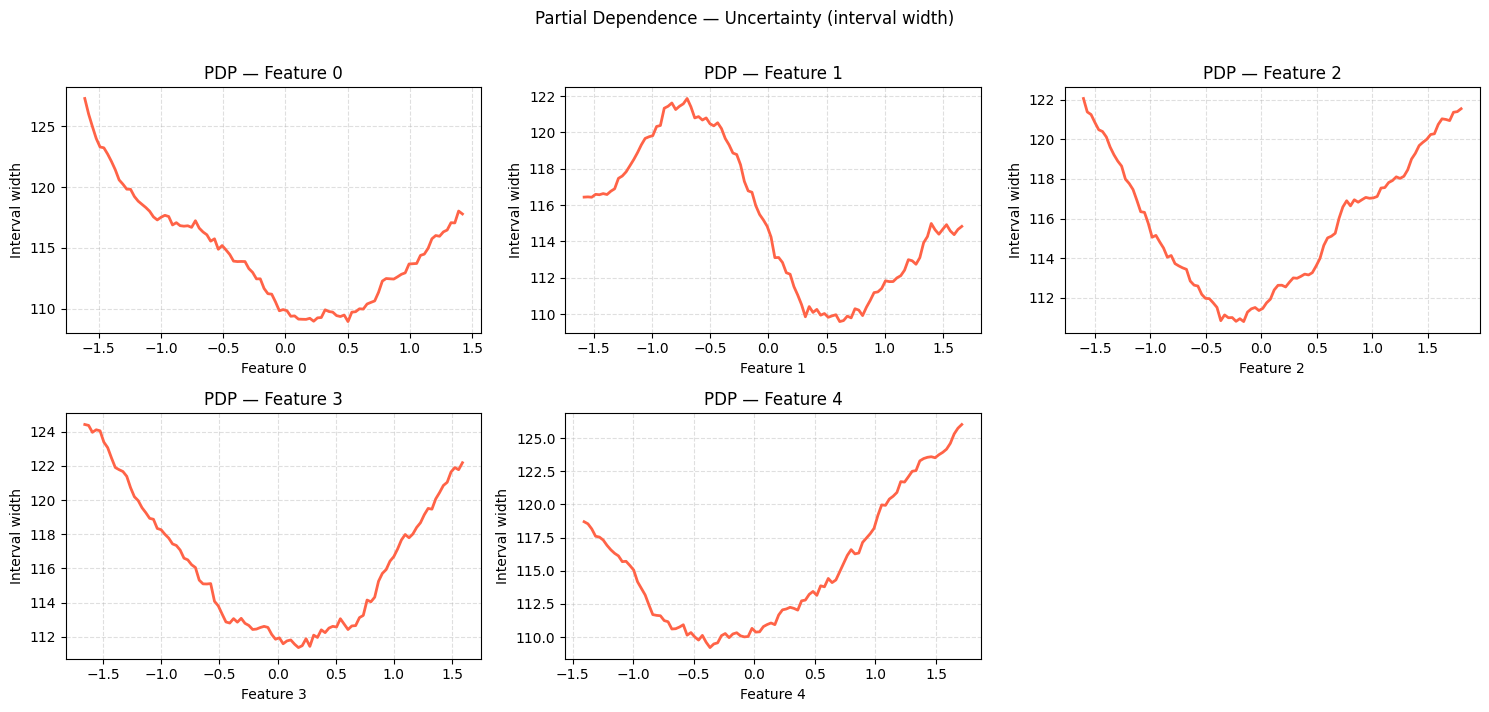

In [10]:
result = pipeline.explain_uncertainty(X_test)

In [11]:
pdp_exp = result_pdp.explanation_values
print(f"PDP values shape:  {pdp_exp.values.shape}  (n_features, grid_resolution)")
print(f"Feature names:     {pdp_exp.feature_names}")
print(f"Grid[0] range:     [{pdp_exp.grid_values[0].min():.2f}, {pdp_exp.grid_values[0].max():.2f}]")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 115.07
Intervalo min: 73.81
Intervalo max: 191.76


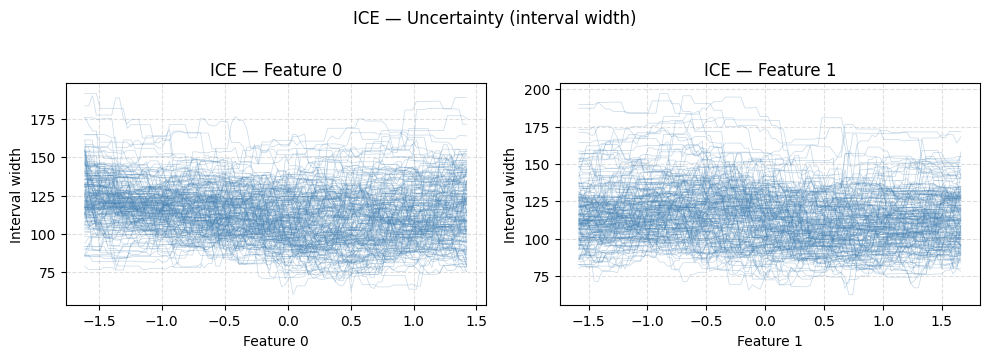

In [12]:
result = pipeline.explain_uncertainty(X_test, features = [0, 1], kind = "individual")

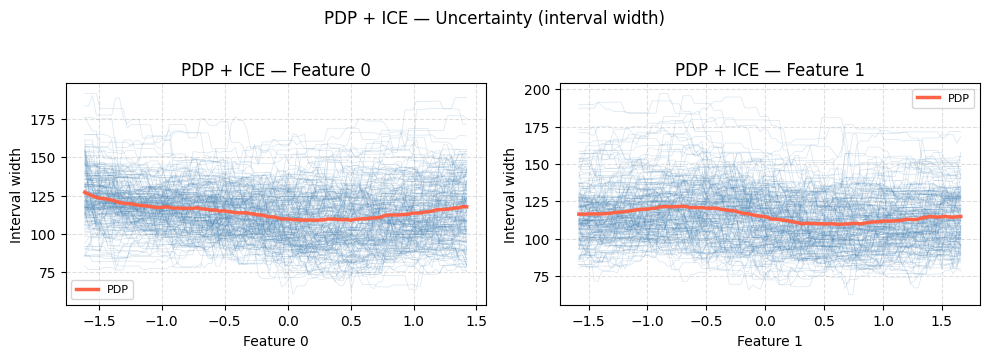

In [13]:
result = pipeline.explain_uncertainty(X_test, features = [0, 1], kind = "both", plot_kind="pdp_ice")

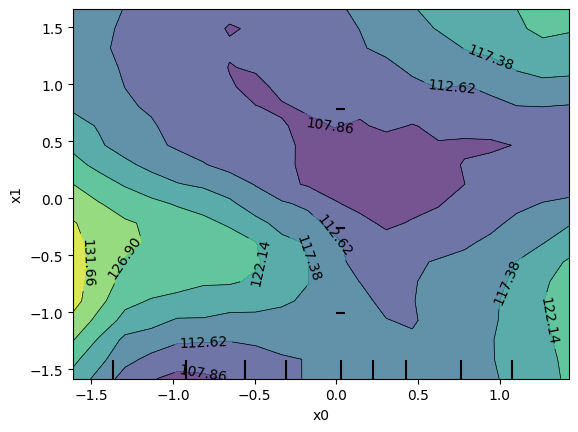

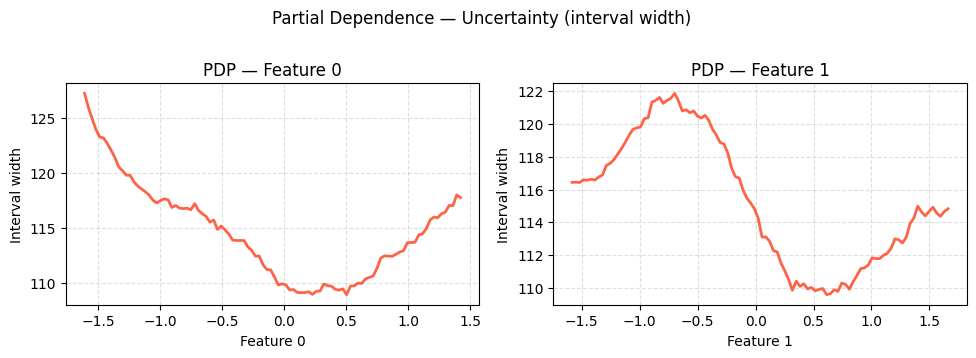

In [14]:
result = pipeline.explain_uncertainty(X_test, features = [(0, 1)])

## Explanation using LIME 

In [33]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized", 
    xai_method="lime",
)

In [34]:
pipeline.fit(X_train, y_train, X_calib, y_calib)

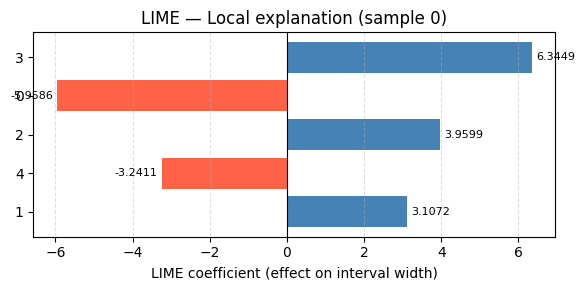

In [35]:
result = pipeline.explain_uncertainty(X_test[1:2, :])

## Usando CQR

In [ ]:
pipeline = UncertaintyExplanationPipeline(
    conformal_method="cqr",
    lower_model=GradientBoostingRegressor(loss="quantile", alpha=0.05),
    upper_model=GradientBoostingRegressor(loss="quantile", alpha=0.95),
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)


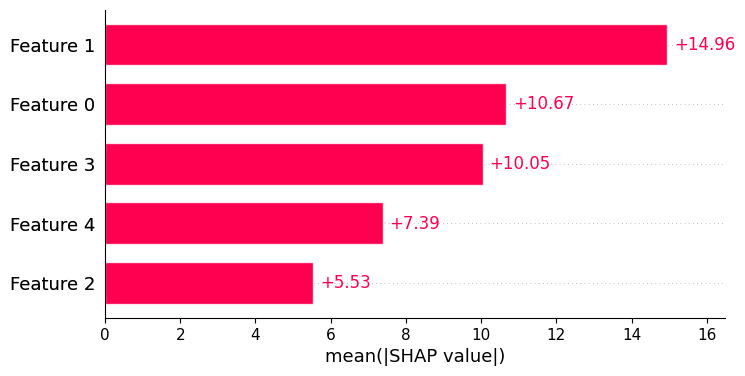

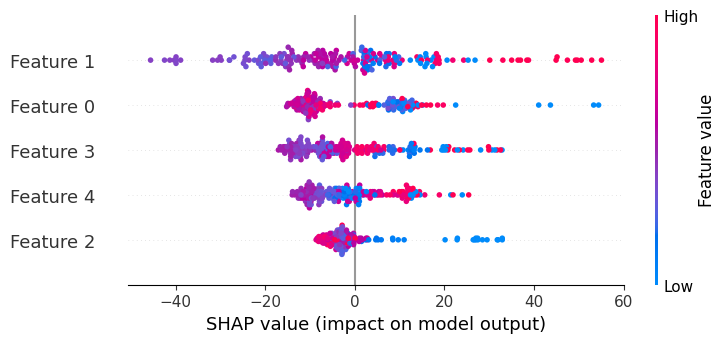

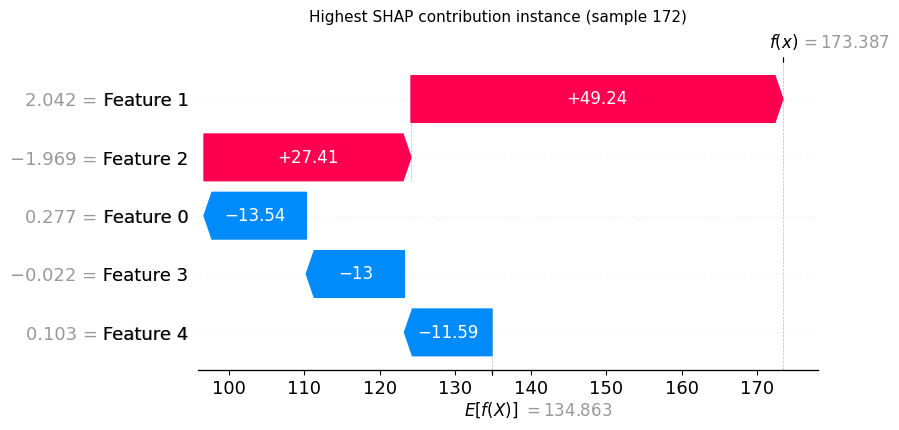

In [37]:
result = pipeline.explain_uncertainty(X_test)

## Varios métodos conformal

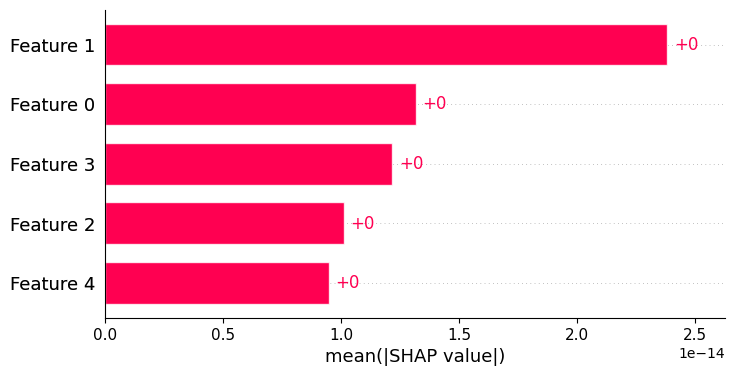

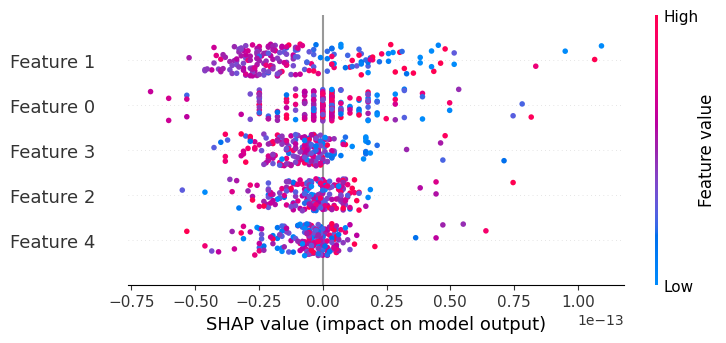

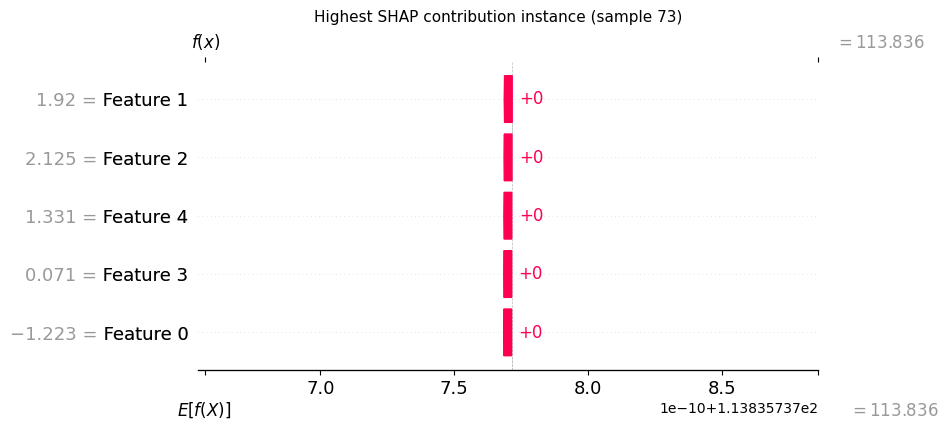

In [39]:
pipeline = UncertaintyExplanationPipeline(
    model=model,
    conformal_method="standard",
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)
result = pipeline.explain_uncertainty(X_test)

ExactExplainer explainer: 201it [00:15,  4.36it/s]                         


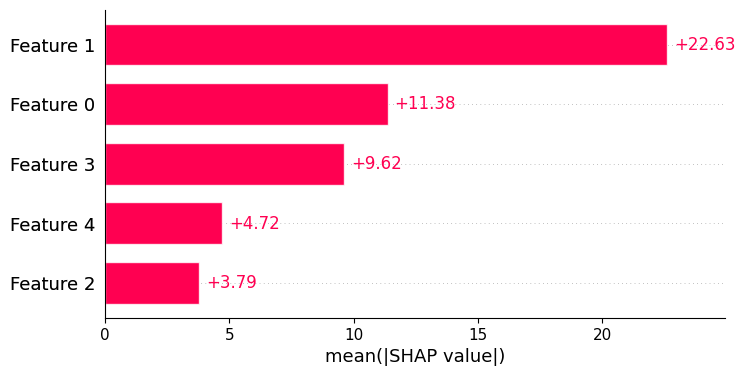

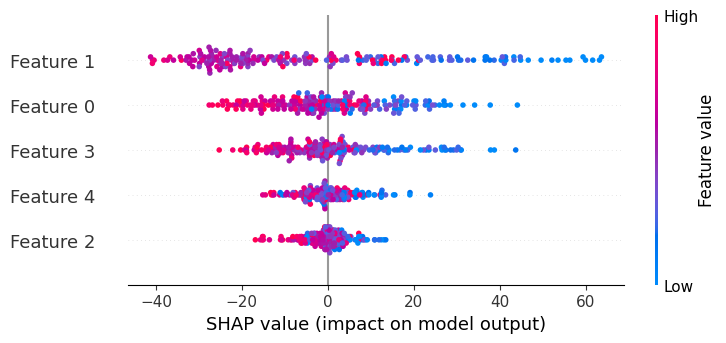

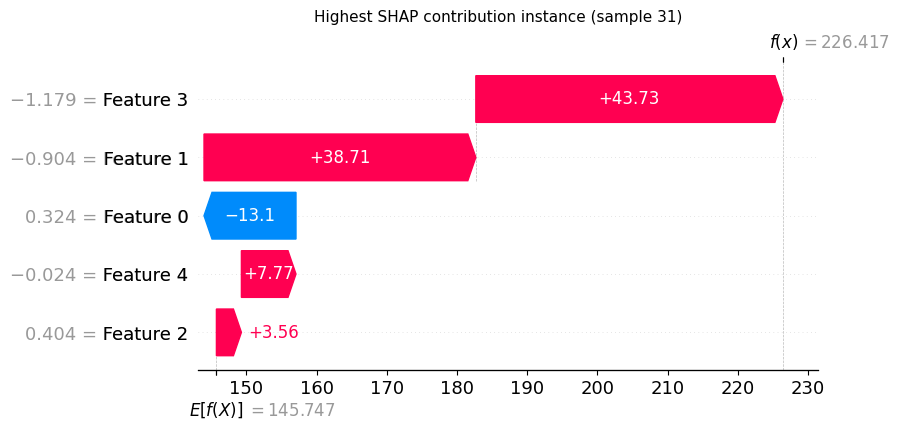

In [40]:
pipeline = UncertaintyExplanationPipeline(
    model=model,
    conformal_method="mondrian",
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)
result = pipeline.explain_uncertainty(X_test)

ExactExplainer explainer: 201it [00:51,  3.10it/s]                         


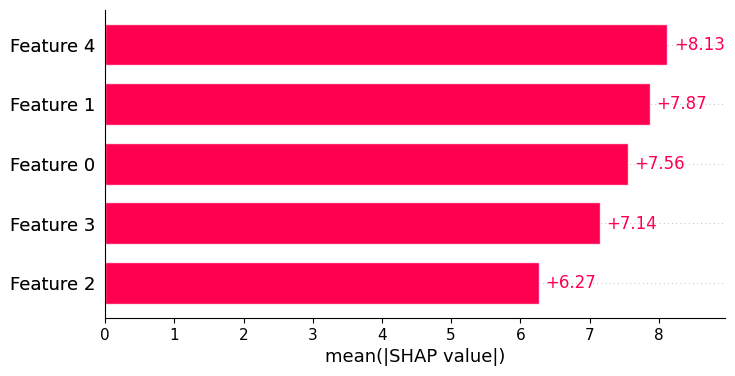

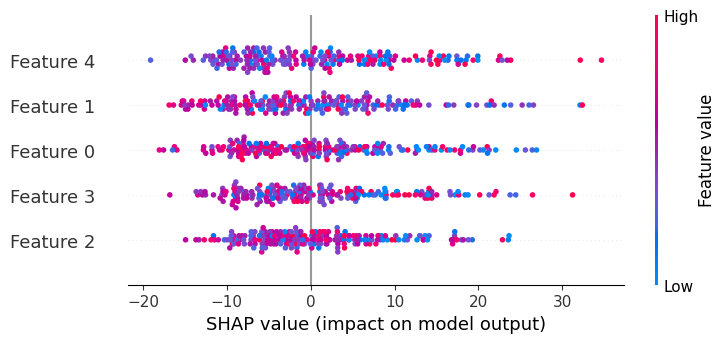

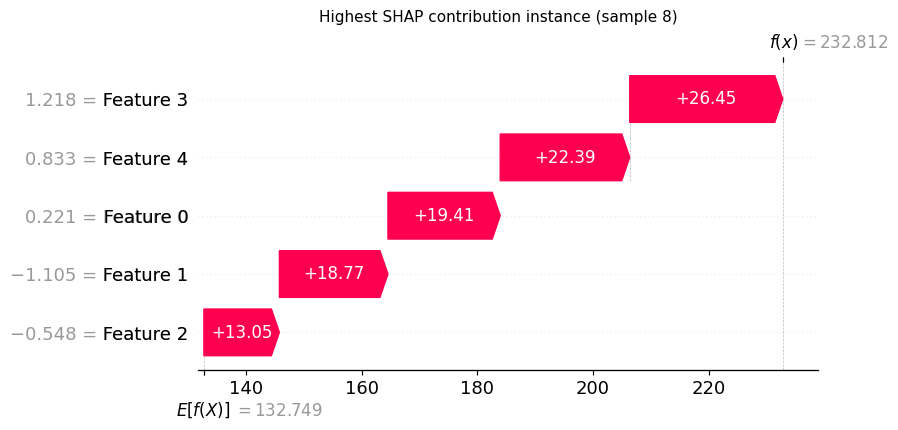

In [41]:
pipeline = UncertaintyExplanationPipeline(
    model=model,
    conformal_method="normalized_mondrian",
    xai_method="shap",
)
pipeline.fit(X_train, y_train, X_calib, y_calib)
result = pipeline.explain_uncertainty(X_test)

## Datos reales


In [15]:
from sklearn.datasets import fetch_openml

bike = fetch_openml(
    name="Bike_sharing_demand",
    version=2,
    as_frame=True
)

df = bike.frame

In [16]:
df = df.loc[:, ["temp", "feel_temp", "humidity", "windspeed", "count"]]

In [17]:
X = df.drop(columns=["count"])
y = df["count"]

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

In [19]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [21]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized",
)

In [22]:
pipeline.fit(X_train, y_train, X_cal, y_cal)

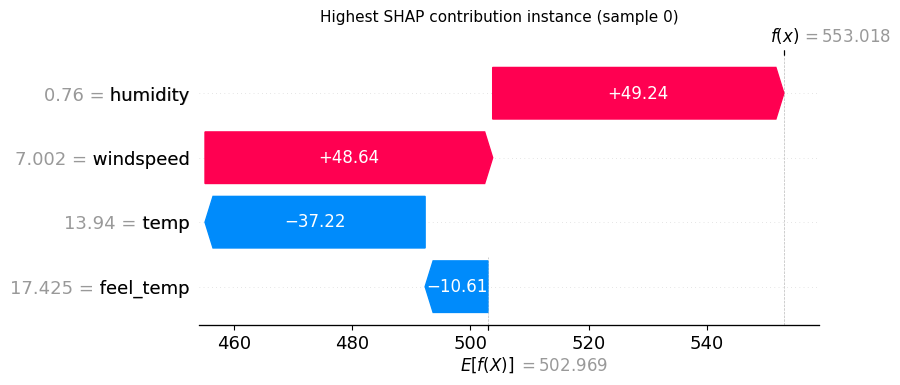

In [17]:
result = pipeline.explain_uncertainty(X_test.iloc[1:2, :])

ExactExplainer explainer: 3477it [09:28,  6.05it/s]                          


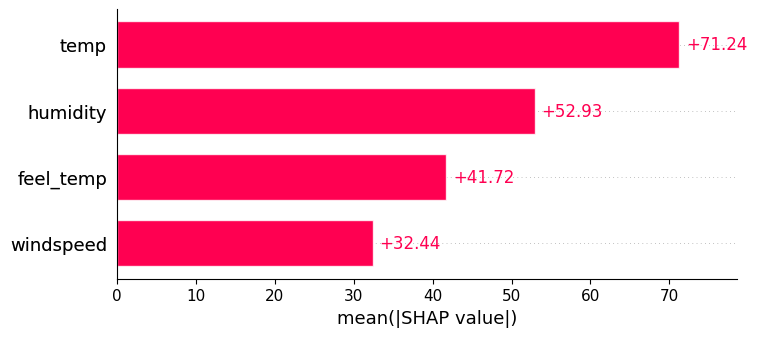

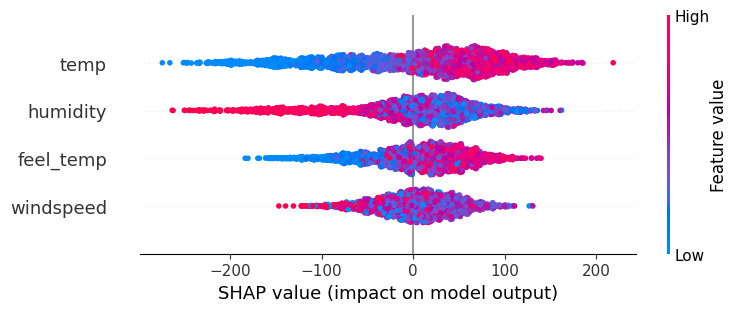

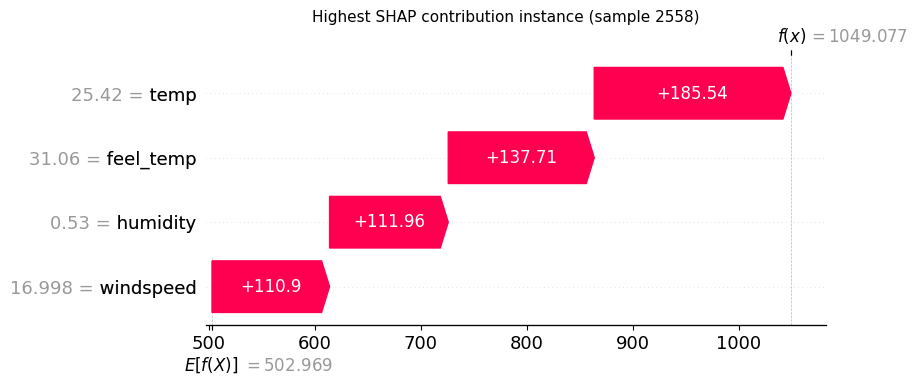

In [23]:
result_shap = pipeline.explain_uncertainty(X_test)

In [20]:
print("Keys:", list(vars(result_shap).keys()))
print(f"\nIntervalo promedio: {result_shap.interval_width.mean():.2f}")
print(f"Intervalo min: {result_shap.interval_width.min():.2f}")
print(f"Intervalo max: {result_shap.interval_width.max():.2f}")

Keys: ['lower', 'upper', 'interval_width', 'explanation_values']

Intervalo promedio: 513.82
Intervalo min: 41.12
Intervalo max: 1049.08


### LIME

In [23]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized",
    xai_method="lime"
)
pipeline.fit(X_train, y_train, X_cal, y_cal)

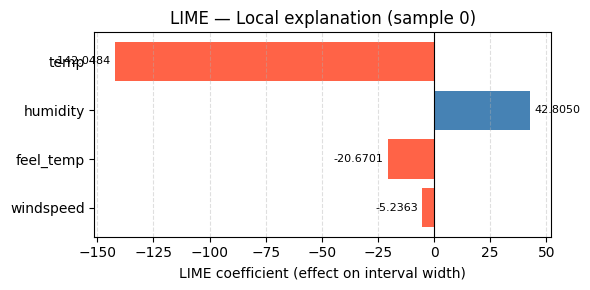

In [24]:
result = pipeline.explain_uncertainty(X_test.iloc[1:2, :])

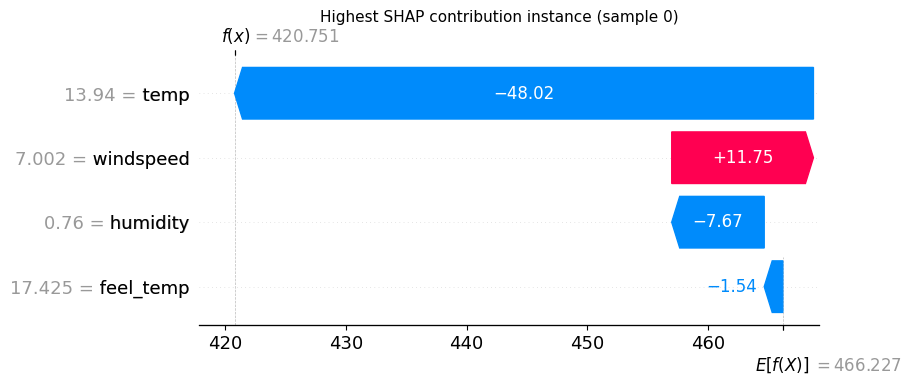

In [29]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    lower_model=GradientBoostingRegressor(loss="quantile", alpha=0.05),
    upper_model=GradientBoostingRegressor(loss="quantile", alpha=0.95),
    conformal_method="cqr",
    xai_method="shap"
)
pipeline.fit(X_train, y_train, X_cal, y_cal)
result = pipeline.explain_uncertainty(X_test.iloc[1:2, :])

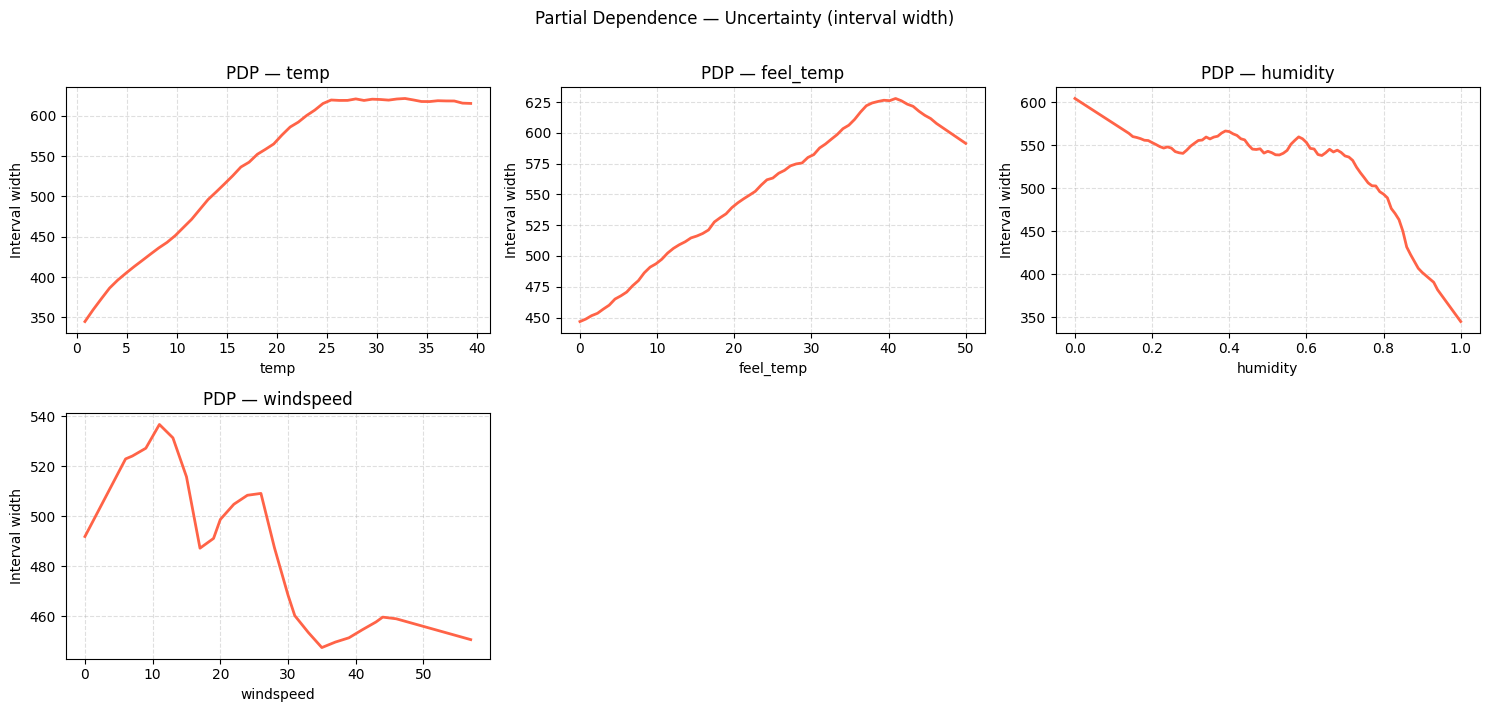

In [25]:
pipeline = UncertaintyExplanationPipeline(
    model,
    confidence=0.9,
    conformal_method="normalized",
    xai_method="pdp"
)
pipeline.fit(X_train, y_train, X_cal, y_cal)
result = pipeline.explain_uncertainty(X_test)

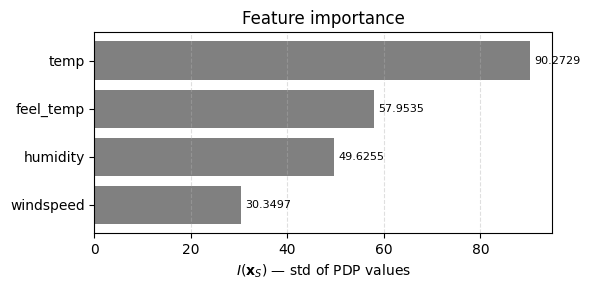

In [27]:
result = pipeline.explain_uncertainty(X_test, plot_kind="importance")

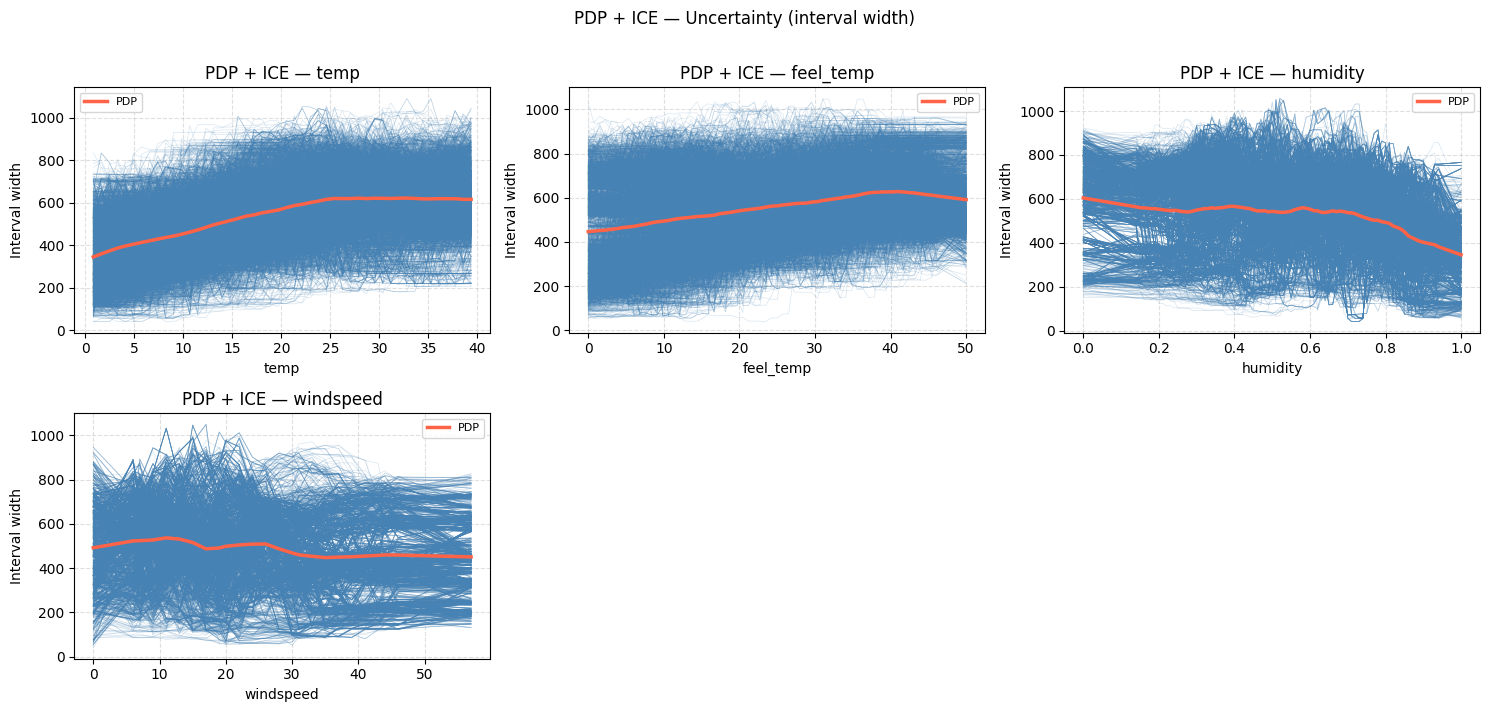

In [28]:
result = pipeline.explain_uncertainty(X_test, kind = "both")

## Explicar diferentes métricas de incertidumbre

El parámetro `uncertainty_metric` permite explicar diferentes aspectos del intervalo de predicción:

- `"width"` (default) — el ancho del intervalo (`upper - lower`): cuán incierto es el modelo
- `"lower"` — el límite inferior: factores que hacen más pesimista la predicción
- `"upper"` — el límite superior: factores que hacen más optimista la predicción  
- `"midpoint"` — el punto medio del intervalo (`(lower + upper) / 2`): la predicción central

### Ejemplo: Explicar el límite inferior con SHAP

In [ ]:
pipeline_lower = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="shap",
    uncertainty_metric="lower",  # Explicar el límite inferior
)
pipeline_lower.fit(X_train, y_train, X_cal, y_cal)
result_lower = pipeline_lower.explain(X_test.iloc[1:2, :], plot_kind="waterfall")

In [ ]:
### Ejemplo: Explicar el límite superior con SHAP

### Ejemplo: Explicar el límite superior con SHAP

In [ ]:
pipeline_upper = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="shap",
    uncertainty_metric="upper",  # Explicar el límite superior
)
pipeline_upper.fit(X_train, y_train, X_cal, y_cal)
result_upper = pipeline_upper.explain(X_test.iloc[1:2, :], plot_kind="waterfall")

### Ejemplo: Explicar el punto medio del intervalo con PDP

In [ ]:
pipeline_pdp_midpoint = UncertaintyExplanationPipeline(
    model=RandomForestRegressor(n_estimators=100, random_state=42),
    confidence=0.9,
    conformal_method="normalized",
    xai_method="pdp",
    uncertainty_metric="midpoint",  # Explicar el punto medio (predicción central)
)
pipeline_pdp_midpoint.fit(X_train, y_train, X_cal, y_cal)
result_midpoint = pipeline_pdp_midpoint.explain(
    X_test,
    plot_kind="pdp",
    kind="average",
)

### Comparación de métricas con LIME

In [ ]:
sample_idx = 0  # Primera muestra de test

results_by_metric = {}

for metric in ["width", "lower", "upper", "midpoint"]:
    pipeline = UncertaintyExplanationPipeline(
        model=RandomForestRegressor(n_estimators=100, random_state=42),
        confidence=0.9,
        conformal_method="normalized",
        xai_method="lime",
        uncertainty_metric=metric,
    )
    pipeline.fit(X_train, y_train, X_cal, y_cal)
    result = pipeline.explain(X_test.iloc[sample_idx:sample_idx+1, :], show_plots=False)
    results_by_metric[metric] = result

# Comparar los coeficientes LIME para cada métrica
print("LIME coefficients para la muestra", sample_idx)
print("=" * 80)
for metric, result in results_by_metric.items():
    exp = result.explanation_values
    coefs = exp.local_coefficients[0]
    print(f"\n{metric.upper()}:")
    for feat_idx, coef in enumerate(coefs):
        feat_name = X_test.columns[feat_idx] if hasattr(X_test, 'columns') else f"feat_{feat_idx}"
        print(f"  {feat_name:15s}: {coef:+.6f}")